# Spatial and Temporal Analysis of Urban Issue Reports in Zurich #

## Data Preparation and Cleaning ##
The raw datasets are loaded and prepared for spatial and temporal analysis. First, the datasets are loaded and the relevant variables for each dataset are selectet to keep the dataframes structured. The column names are then standardized to avoid merge conflicts across datasets. Also the completeness of the datasets is verified before further analysis. THe three datasets are prepared as follows:

- The reports data set is prepared by converting timestamps into datetime format. To enable spatial analysis, a GeoDataFrame is created and the Swiss coordinate reference system (Swiss LV95 / EPSG:2056) is assigned.

- In the neighborhoods dataset, the geometry column is converted from string to geometry format. The Swiss coordinate reference system (LV95 / EPSG:2056) is also assigned to ensure spatial consistency across datasets.

- For the population dataset, only observations from the year 2025 are retained. This represents the most recent population data available in the dataset.


In [83]:
import pandas as pd
import matplotlib.pyplot as plt
from shapely.geometry import Point
from shapely import wkt
import geopandas as gpd
import mapclassify
import sys
import os
import importlib
from pathlib import Path



#The scripts folder is linked to import custom functions into the notebook.
scripts_dir = Path("../scripts")
sys.path.append(scripts_dir)

data_dir =Path("../data")
raw_dir = data_dir/ "raw"
processed_dir = data_dir /"processed"

output_dir = Path("../outputs")

raw_reports =  pd.read_csv(raw_dir/"zwn_meldungen.csv")
raw_neighborhoods = pd.read_csv(raw_dir/"quartiere_zürich.csv")
raw_population_size = pd.read_csv(raw_dir/"populationsize_zh.csv")



reports = raw_reports[["service_name","requested_datetime","e","n","status","updated_datetime"]]
neighborhoods = raw_neighborhoods[["qname","geometry"]]
population_size = raw_population_size[["QuarLang","AnzBestWir","StichtagDatJahr"]]


new_names_reports = {
    "service_name":"Category",
    "e":"East",
    "n":"North",
    "requested_datetime":"Report_time",
    "updated_datetime":"Resolved_time",
    }
reports = reports.rename(columns=new_names_reports)

new_names_neighborhoods = {
    "qname":"Neighborhoods",
    "geometry": "Geometry",
    }
neighborhoods = neighborhoods.rename(columns=new_names_neighborhoods)

new_names_population_size = {
    "QuarLang":"Neighborhoods",
    "AnzBestWir":"Population_size",
    "StichtagDatJahr":"Year"
    }
population_size = population_size.rename(columns=new_names_population_size)


reports.isna().sum()         # none missing values are found
neighborhoods.isna().sum()   # none missing values are found
population_size.isna().sum() # none missing values are found


#-------------------------------------------------------------------------------------------------------------------------
# Prepare reports dataset
#-------------------------------------------------------------------------------------------------------------------------

reports["Report_time"] = pd.to_datetime(reports["Report_time"], format ="%Y-%m-%dT%H:%M:%S")
reports["Resolved_time"] = pd.to_datetime(reports["Resolved_time"], format ="%Y-%m-%dT%H:%M:%S")


reports_gdf = gpd.GeoDataFrame(
    reports,
    geometry=gpd.points_from_xy(reports["East"], 
    reports["North"])
)
# Assign coordinate reference system (Swiss LV95 / EPSG:2056) for spatial join
reports_gdf = reports_gdf.set_crs(epsg=2056)

reports_gdf.to_csv(processed_dir/"reports_gdf.csv")

#-------------------------------------------------------------------------------------------------------------------------
# Prepare neighborhoods dataset
#-------------------------------------------------------------------------------------------------------------------------

neighborhoods["Geometry"] = neighborhoods["Geometry"].apply(wkt.loads)


neighborhoods_gdf = gpd.GeoDataFrame(
    neighborhoods,
    geometry="Geometry")

# Assign coordinate reference system (Swiss LV95 / EPSG:2056) for spatial join
neighborhoods_gdf = neighborhoods_gdf.set_crs(epsg=2056)

neighborhoods_gdf.to_csv(processed_dir/"neighborhoods_gdf.csv")

#-------------------------------------------------------------------------------------------------------------------------
# Prepare poulation size dataset
#-------------------------------------------------------------------------------------------------------------------------

population_size_2025= population_size[population_size["Year"]	== 2025]

population_size_2025.to_csv(processed_dir/"population_size_2025.csv")





## Spatial Join ##
A spatial join is performed to link service reports with their corresponding neighborhoods.

A left join is used to retain all reports, even if some do not match a neighborhood polygon.\
"Intersects" is preferred over "within" to minimize unmatched observations.

In [84]:
reports_gdf_with_neighborhoods_gdf = gpd.sjoin(reports_gdf,neighborhoods_gdf, how="left", predicate ="intersects")

## Question 1: How does the number of reports vary across neighborhoods?
As an overview, the distribution of reports across neighborhoods is analyzed to capture spatial differences in reporting intensity.

1. The number of reports is aggregated by neighborhood. 
2. The resulting dataset is  merged with the neighborhood boundaries and the population data to enable spatial comparison. 
3. The number of reports is subsequently normalized by population size to account fo differences in neighborhood size. \
For better interpretability, the values are scaled per 1000 inhabitants.
4. The data in visualized in a choropleth map, using the natural breaks method to define class intervals. \
The break method is choosen because data is not evenly distributed. A histogram is created to determine an appropriate number of class breaks. \
 For better readability the legend is adjusted and neighborhood labels are added to the map.

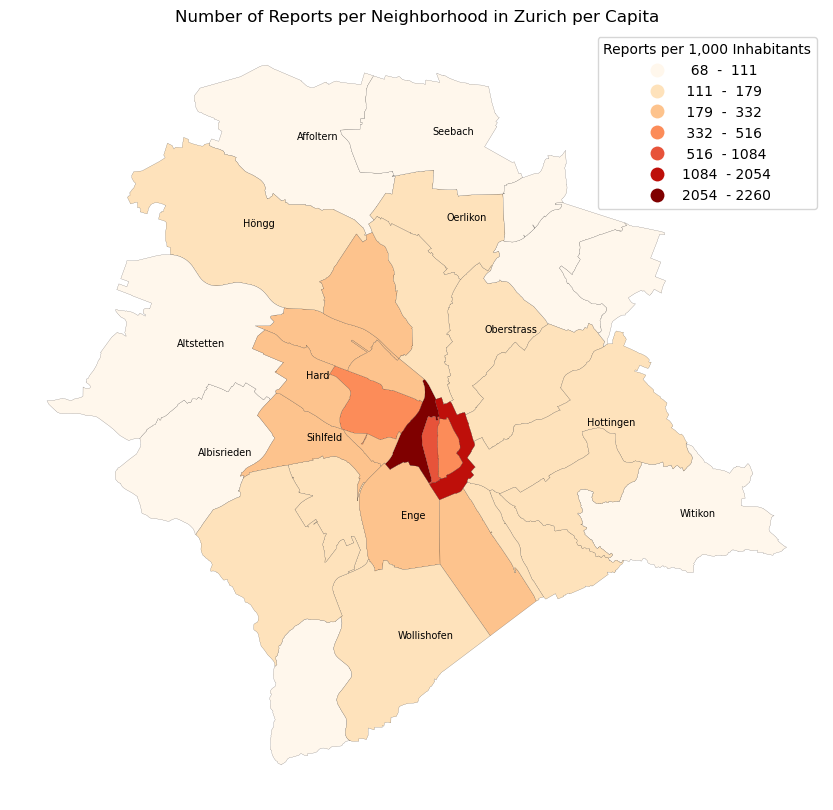

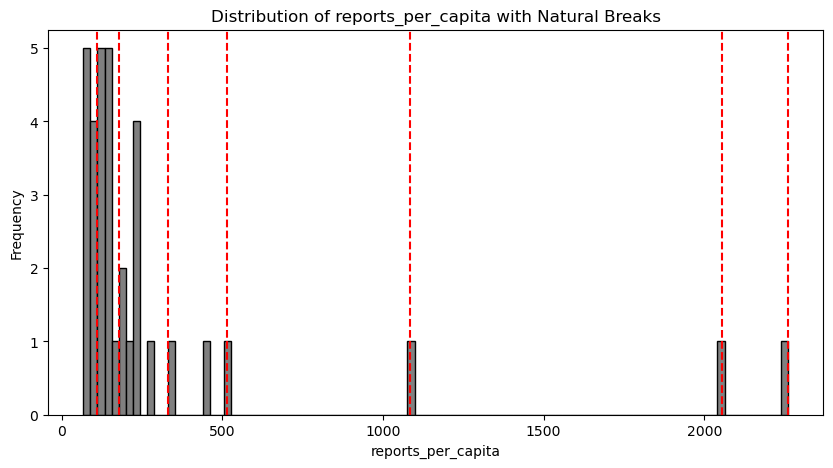

In [85]:
#---------------------------------------------------------------------------------------------------------------------
# Build Analysis Dataset
#---------------------------------------------------------------------------------------------------------------------

# # Aggregate reports per neighborhood to compare reporting intensity across neighborhoods
reports_count = reports_gdf_with_neighborhoods_gdf.groupby(["Neighborhoods"]).size().reset_index(name="count")

reports_count_gdf = neighborhoods_gdf.merge(reports_count, on="Neighborhoods",how="left")
reports_count_pop_gdf = reports_count_gdf.merge(population_size_2025, on="Neighborhoods",how="left")

# Scale values per 1,000 inhabitants for better readability
reports_count_pop_gdf["reports_per_capita"] = (reports_count_pop_gdf["count"]/reports_count_pop_gdf["Population_size"] *1000)

#----------------------------------------------------------------------------------------------
# Create Chlorpleth Map
#----------------------------------------------------------------------------------------------

fig, ax = plt.subplots(figsize=(20,10)) 

reports_count_pop_gdf.plot(
    column="reports_per_capita",
    scheme = "naturalbreaks",
    k = 7,
    edgecolor = "black",
    legend=True,
    linewidth = 0.1,
    cmap="OrRd",
    ax=ax, 
    legend_kwds={"title": "Reports per 1,000 Inhabitants","fmt": "{:.0f}"})

ax.set_title("Number of Reports per Neighborhood in Zurich per Capita")
ax.axis("off")

# improve map readability by enhancing legend formatting and adding neighborhoods labels
functions.clean_legend_labels(ax)
functions.add_labels_zurich(ax,reports_count_pop_gdf,names=["Affoltern","Seebach","Oerlikon","Höngg","Altstetten",
                                                            "Albisrieden","Enge","Wollishofen","Witikon","Hottingen",
                                                            "Sihlfeld","Hard","Oberstrass"])

plt.show()
fig.savefig(output_dir / "Q1_Reports_per_Neighborhood.png")


#----------------------------------------------------------------------------------------------------------------------------------------
# Create Histogram
#----------------------------------------------------------------------------------------------------------------------------------------
functions.histogram_natural_breaks(reports_count_pop_gdf,column="reports_per_capita",k=7)



## Results of Question 1 
The map shows spatial differences in the intensity of reports across Zurich. Higher values are mainly concentraded in central neighborhoods. \
Neighborhoods at the edge of Zurich show relatively low reporting rates per capita.

## Question 2: What categories of problems are most frequently reported in each neighbourhood? ##
To gain insight into the most common issues, the most frequently reported categroy is extracted for each neighborhood. 
1. The number of reports is aggregated by neighborhood and category.
2. The most frequently reported category by neighborhood is extraced by sorting the counts in descending order and selecting the top category for each neighborhood
3. The data is visualized in a categorical map, where each neighborhood is colored according to its most common report category.

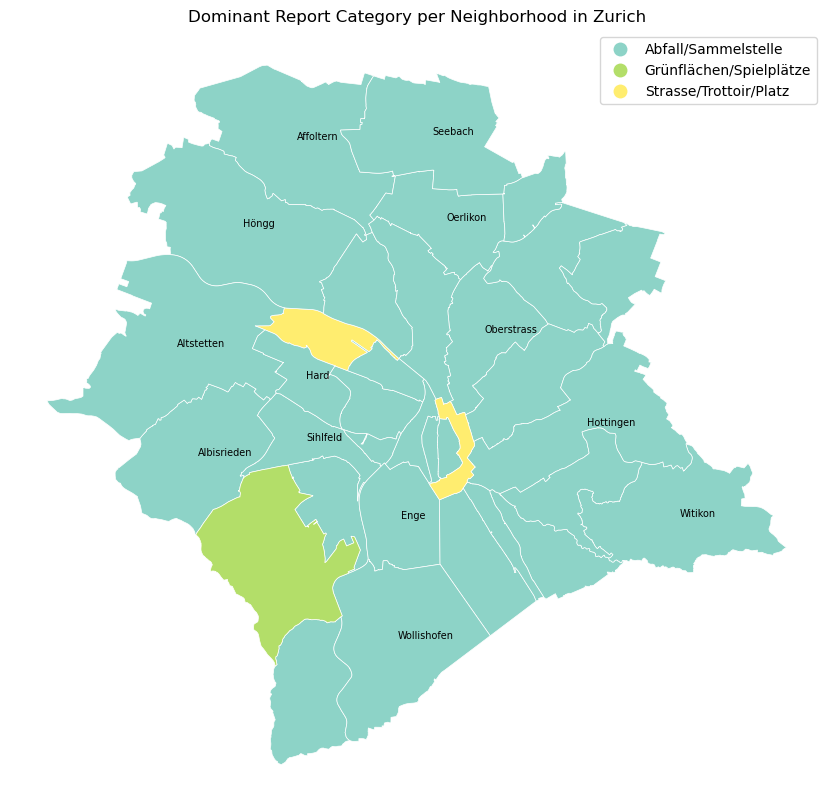

In [86]:
#---------------------------------------------------------------------------------------------------
# Build Analysis Dataset
#---------------------------------------------------------------------------------------------------
count_category = reports_gdf_with_neighborhoods_gdf.groupby(["Neighborhoods","Category"]).size().reset_index(name="count")


# Extract the most reported category per neighborhood to compare spatial differences in main issue types
maxcount = count_category.sort_values(["Neighborhoods", "count"], ascending=[True, False]).drop_duplicates("Neighborhoods")

maxcount_gdf = neighborhoods_gdf.merge(maxcount, on="Neighborhoods",how="left")

#---------------------------------------------------------------------------------------------------------
# Create Categoric Map
#---------------------------------------------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(20,10))

maxcount_gdf.plot(
    column="Category",
    categorical=True,
    edgecolor = "white",
    legend=True,
    linewidth = 0.5,
    cmap = "Set3",
    ax=ax,)
 
ax.axis("off")
ax.set_title("Dominant Report Category per Neighborhood in Zurich") 

functions.add_labels_zurich(ax,maxcount_gdf,names=["Affoltern","Seebach","Oerlikon","Höngg","Altstetten",
                                                            "Albisrieden","Enge","Wollishofen","Witikon","Hottingen",
                                                            "Sihlfeld","Hard","Oberstrass"])
plt.show()
fig.savefig(output_dir / "Q2_Dominant_Report_Category.png")




## Results of Question 2
The map shows that in almost all neighborhoods the most frequently reported category is "Abfall/Sammelstelle. Only in the neighborhoods Hochschulen and Escher Wyss, the categroy "Strasse/Trottoir/Platz" is dominant. In addition, in Friesenberg is the dominant category "Grünflächen/Spielplätze".

## Question 3: Is the "Abfall/Sammelstelle" issue concentrated in particular neighbourhoods? 
Since "Abfall/Sammelstelle" seems to be te dominant report category, this analysis focuses on whether this issue is spatially concentrated in specific neighborhoods.

1. The dataset is filtered to include only reports of the category "Abfall/Sammelstelle"
2. The filtered data is merged with population and neighborhood boundary data
3. The number of reports is subsequently normalized by population size to account fo differences in neighborhood size.
   For better interpretability, the values are scaled per 1000 inhabitants.
4. The data in visualized in a choropleth map, using the natural breaks method to define class intervals. \
   The break method is choosen because data is not evenly distributed. A histogram is created to determine an appropriate number of class breaks. \
   For better readability the legend is adjusted and neighborhood labels are added to the map.
   





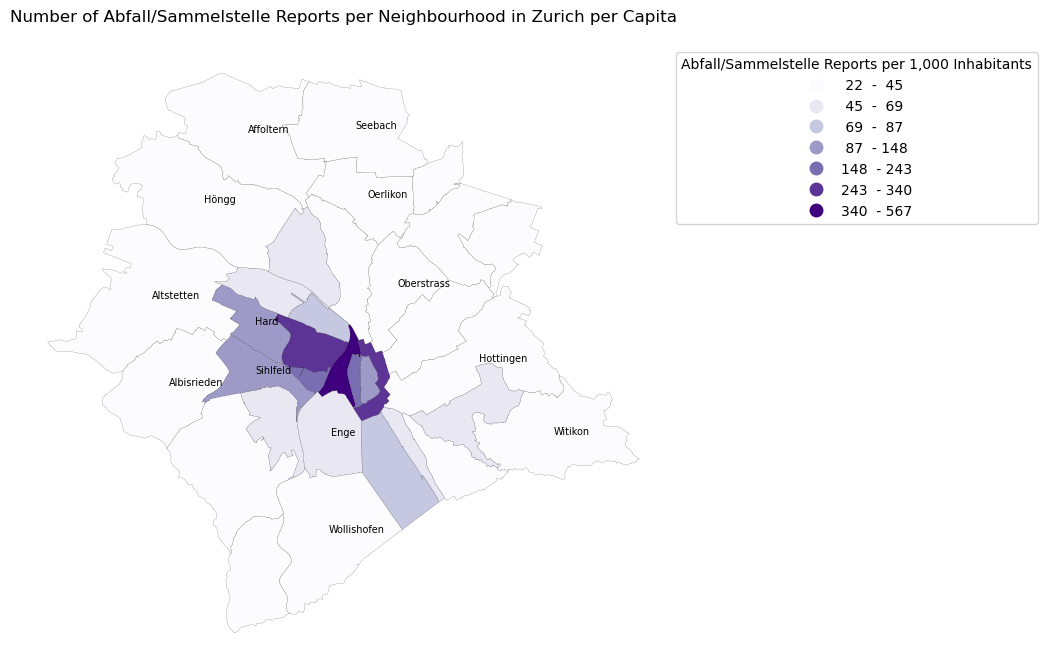

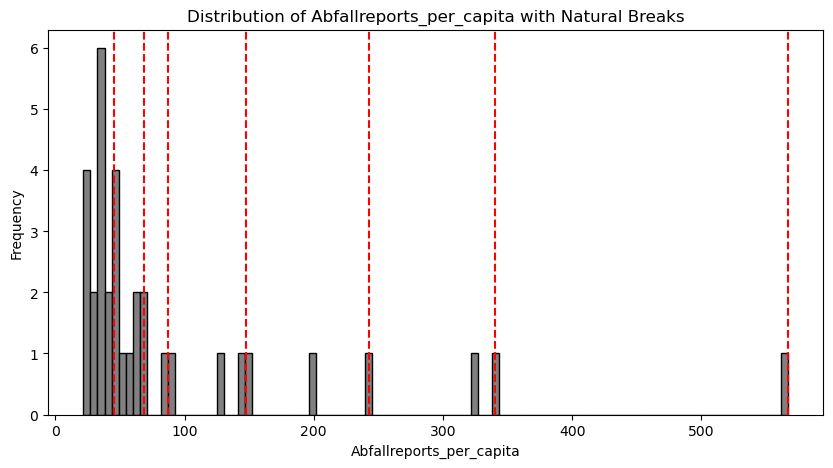

In [87]:
# ------------------------------------------------------------
# Build Analysis dataset
# ------------------------------------------------------------

#filter reports to focus on Abfall/Sammelstelle issues only
filtered_category = count_category[count_category["Category"]=="Abfall/Sammelstelle"]

filtered_category=population_size_2025.merge(filtered_category, on = "Neighborhoods", how="left")
filtered_category_gdf=neighborhoods_gdf.merge(filtered_category, on="Neighborhoods",how="left")

# Scale values per 1,000 inhabitants for better readability
filtered_category_gdf["Abfallreports_per_capita"] = (filtered_category_gdf["count"]/filtered_category_gdf["Population_size"]*1000)


#---------------------------------------------------------------------------------------------------------
# Create Chloropleth Map
#---------------------------------------------------------------------------------------------------------

fig, ax = plt.subplots(figsize=(16,8)) 


filtered_category_gdf.plot(
    column="Abfallreports_per_capita",
    scheme = "naturalbreaks",
    k = 7,
    edgecolor = "black",
    legend=True,
    linewidth = 0.1,
    cmap="Purples",
    ax=ax, 
    legend_kwds={"title": "Abfall/Sammelstelle Reports per 1,000 Inhabitants","fmt": "{:.0f}","loc":"upper left","bbox_to_anchor":(1, 1)})
              
ax.set_title("Number of Abfall/Sammelstelle Reports per Neighbourhood in Zurich per Capita")
ax.axis("off")

# improve map readability by enhancing legend formatting and adding neighborhoods labels
functions.clean_legend_labels(ax)
functions.add_labels_zurich(ax,filtered_category_gdf,names=["Affoltern","Seebach","Oerlikon","Höngg","Altstetten",
                                                            "Albisrieden","Enge","Wollishofen","Witikon","Hottingen",
                                                            "Sihlfeld","Hard","Oberstrass"])

#---------------------------------------------------------------------------------------------------------
# Create Histogram
#---------------------------------------------------------------------------------------------------------
functions.histogram_natural_breaks(filtered_category_gdf,column="Abfallreports_per_capita",k=7)
fig.savefig(output_dir / "Q3_Abfall_Report_Distribution")







## Results of Question 3
The resulting map shows a similar pattern to the map in Question 1, which analyzed the overall distribution of reports. This suggests once more that Abfall/Sammelstelle is likely the dominant issue which drives the overall spatial pattern of reports.
Reports of the category "Abfall/Sammelstelle" are concentrated in central neighborhoods of Zurich. In particular, the neighborhoods City, Hochschulen und Langstrasse show the highest number of reports per 1000 inhabitants. Peripheral Neighborhoods show significantly lower reporting rates.

## Question 4: How does the processing time for "Abfal/Sammelstelle" reports vary across neighborhoods in Zurich ##
To improve the report handling process, this analysis investigates how processing times for "Abfall/Sammelstelle" reports vary across neighborhoods.
1. The dataset is filtered to include only resolved "Abfall/Sammelstelle" reports, as processing times cannot be computed for unresolved cases.
2. A mean processing function is applied. It filters th dataset to the selected category "Abfall/Sammelstelle". The difference between the resolution timestamp and the reporting timestamp is computed to obtain the processing duration. These values are aggregated by neighborhood to calculate the mean processing time. Finally, the results are converted into days for better interpretability.
3. The dataset is than merged with the neighborhood boundary to enable spatial visualization
4. The data in visualized in a choropleth map, using the natural breaks method to define class intervals. \
   The break method is choosen because data is not evenly distributed. A histogram is created to determine an appropriate number of class breaks. \
   For better readability the legend is adjusted and neighborhood labels are added to the map.
   
   

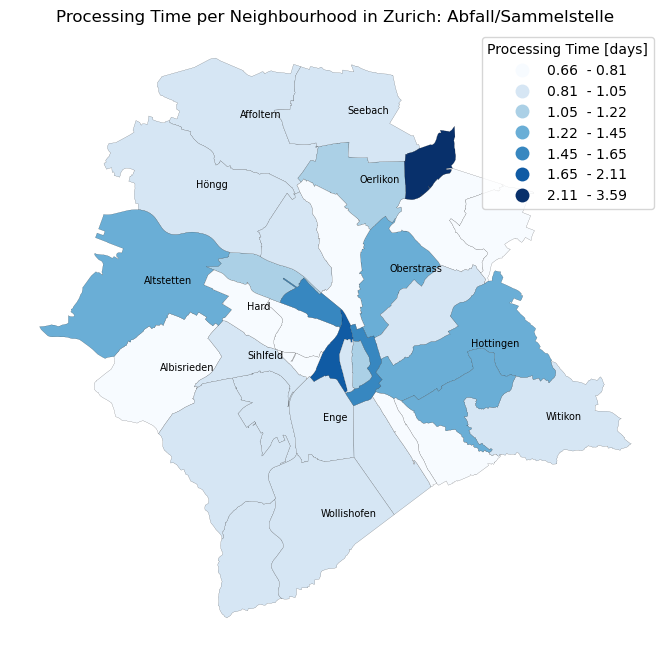

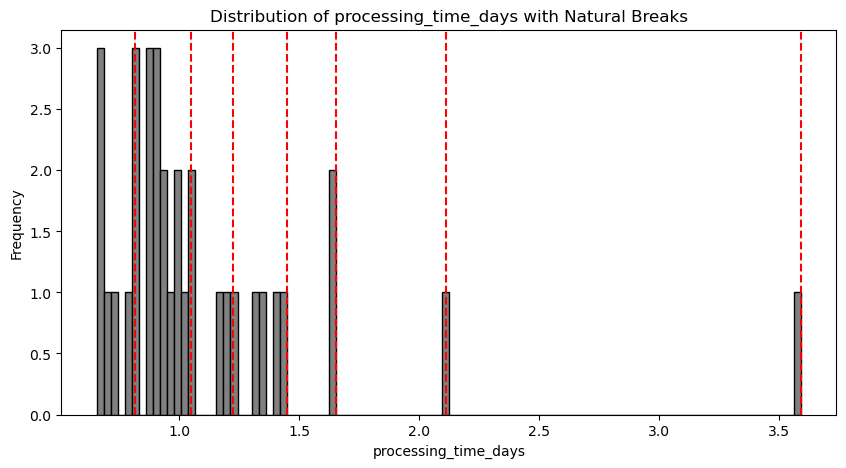

In [88]:
# ----------------------------------------------------------------------------------------------------------------------------------------
# Build Analysis dataset
# ----------------------------------------------------------------------------------------------------------------------------------------

# Only resolved reports are included, since processing time cannot be calculated for unresolved cases
reports_fixed = reports_gdf_with_neighborhoods_gdf [reports_gdf_with_neighborhoods_gdf["status"] =="fixed - council"]

mean_days = functions.calculate_mean_processing_time(reports_fixed,"Abfall/Sammelstelle")
mean_days_gdf = neighborhoods_gdf.merge(mean_days, on="Neighborhoods",how="left")

#--------------------------------------------------------------------------------
# Create Choropleth Map
#--------------------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(16,8)) 

mean_days_gdf.plot(column="processing_time_days",
            scheme = "naturalbreaks",
            k = 7,
            edgecolor = "black",
            legend=True,
            linewidth = 0.1,
            cmap="Blues",
            ax=ax, #draw the axes on the axes we creaed
            legend_kwds={
                "title": "Processing Time [days]",})
ax.set_title("Processing Time per Neighbourhood in Zurich: Abfall/Sammelstelle")
ax.axis("off")

# improve map readability by enhancing legend formatting and adding neighborhoods labels
functions.clean_legend_labels(ax)
functions.add_labels_zurich(ax,mean_days_gdf,names=["Affoltern","Seebach","Oerlikon","Höngg","Altstetten",
                                                "Albisrieden","Enge","Wollishofen","Witikon","Hottingen",
                                                "Sihlfeld","Hard","Oberstrass"])
fig.savefig(output_dir / "Q4_Abfall_Processing_Time.png")


#--------------------------------------------------------------------------------------------------------------------------------------------------------------
# Create histogram
#----------------------------------------------------------------------------------------------------------------------------------------------------------
functions.histogram_natural_breaks(mean_days_gdf,column="processing_time_days",k=7)


## Results of Question 4
The map shows and uneven distribution of the processing times of "Abfall/Sammelstelle" across Zurich. In central neighborhoods, where the highest number of "Abfall/Sammelstelle" reports are recorded, processing times are relatively high. However, also neighborhoods such as Altstetten, Hottingen and Oberstrass exhibit relatively long processing times. Particularly notable is the neighborhood Saatlen, which shows the longest average processing time.

## Question 5: How do report volumes change overtime per category in Zurich ? ##
To gain an overview oh how reported issues change over time, a temporal analysis of report categories across neighborhoods is conducted.
1. The report dataset is grouped by category and year (only for Reports over one year)
2. The reports are resampled on a monthly basis to aggregate the number of reports per month for each category.
3. Monthly report counts are visualized using line plots with a different color assigned to each category to improve readibility and comparision.

The service issue categories shown in the categorical mao in Question 2 are selected for the temporal analyis to compare trends between dominant issue types. \
The categories can be adjusted depending on the focus of the analysis. In this case, the categories "Abfall/Sammelstelle", "Grünflächen/Spielplätze", "Strasse/Trottoir/Platz" and "Schädlinge" are analyzed. \
For the seasonal analysis the year 2025 is analyzed.



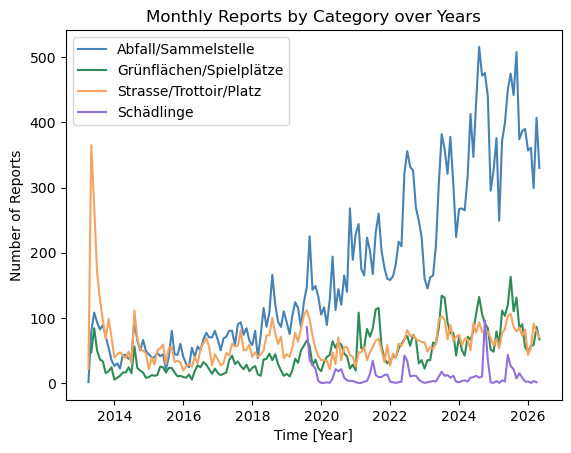

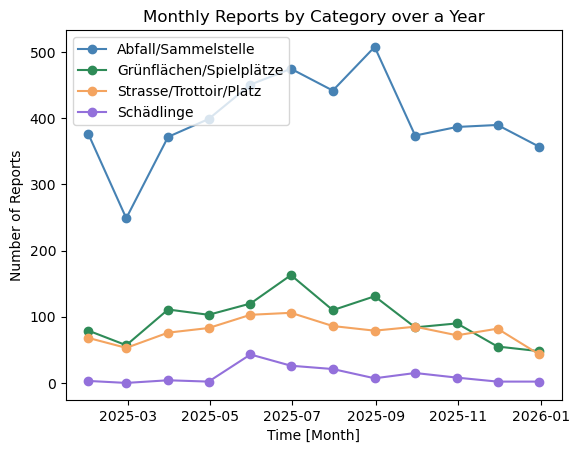

In [89]:
# Visualize long-term temporal trends to identify structural changes over multiple years
functions.plot_category_over_years(reports_gdf_with_neighborhoods_gdf,["Abfall/Sammelstelle","Grünflächen/Spielplätze","Strasse/Trottoir/Platz","Schädlinge"])
fig.savefig(output_dir / "Q5_Reports_over_Years.png")

# Visualize monthly variation within a year to identify seasonal patterns
functions.plot_category_over_a_year(reports_gdf_with_neighborhoods_gdf,["Abfall/Sammelstelle","Grünflächen/Spielplätze","Strasse/Trottoir/Platz","Schädlinge"],year=2025)
fig.savefig(output_dir / "Q5_Reports_over_a_Year.png")

## Results of Question 5
Monthly Reports by Category over years: \
\
The number of reports in the "Abfall/Sammelstelle" category has increased significantly since 2018. While there were around 100 reports per month in 2018, peak moonth recently reached approximately 500 reports. \
In contrast, the "Strasse/Trottoir/Platz" category has remained relatively stable over time, with the exception of 2013. In this year unusuall high number of reports was recorde.\
The "Grünflächen/Spielplätze" category shows a slight upward trend since 2020. The "Schädlinge" category has only ben part of the platform since 2020. Although it occasionally shows peak months, the overall number of reports remain comparatively low. \
The analyis shows also clear monthly fluctuations, which are visible in the recurring ups and downs of the curves. Furthermore, it emphasizes the higher number of reports in the "Abfall/Sammelstelle" category compared to the other categories. \
\
Monthly Reports by Category over a year: \
\
All categories show an increase in the number of reports during the summer months. This seasonal pattern is especially pronounced in the "Abfall/Sammelstelle" category. \
The "Grünlächen/Speilätze" also shows a seasonal effect, with report number typically peaking in July. \
For the "Strasse/Trottoir/Platz" and "Schädlinge" categories, the seasonal increase is less pronounced. However, the data still suggests a slight seasonal dependency, with somewhat higher report numbers during the warmer months.
